<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES18Sim004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def set_seed(seed=42):
    np.random.seed(seed)

def fft_power_spectrum(u, dx=1.0):
    N = len(u)
    U = np.fft.rfft(u - np.mean(u))
    P = (np.abs(U)**2) / N
    k = np.fft.rfftfreq(N, d=dx) * 2*np.pi   # angular wavenumber
    return k, P

def characteristic_scale_from_spectrum(k, P):
    # Exclude k=0 to avoid DC bias
    mask = k > 0
    k_pos = k[mask]; P_pos = P[mask]
    if len(P_pos) == 0:
        return np.nan, np.nan
    k_peak = k_pos[np.argmax(P_pos)]
    lambda0 = 2*np.pi / k_peak
    return k_peak, lambda0

def laplacian_periodic(u):
    return np.roll(u,1) - 2*u + np.roll(u,-1)

def evolve_hes(u0, steps=200, alpha=0.20, beta=0.02, gamma=0.001, dt=0.2, clip=None):
    u = u0.copy()
    for _ in range(steps):
        u += dt*(alpha*laplacian_periodic(u) - beta*u**3 - gamma*u**5)
        if clip is not None:
            u = np.clip(u, -clip, clip)
    return u

def gaussian_correlated_field(N=1024, lambda0=10.0, amplitude=1.0, noise=0.2):
    # Create a Gaussian kernel in k-space around desired k_peak
    x = np.arange(N)
    dx = 1.0
    k = np.fft.rfftfreq(N, d=dx) * 2*np.pi
    k_peak = 2*np.pi / lambda0
    sigma_k = 0.25 * k_peak
    envelope = np.exp(-(k - k_peak)**2 / (2*sigma_k**2))
    phase = np.exp(1j * 2*np.pi * np.random.rand(len(k)))  # random phases
    U = amplitude * envelope * phase
    # Hermitian symmetry for real signal
    u = np.fft.irfft(U, n=N)
    # Add controlled broadband noise
    u += noise * np.random.randn(N)
    return u


Structured void λ0 init: 2.60 → evolved: 157.54
Random void λ0 init:     4.18 → evolved: 107.79


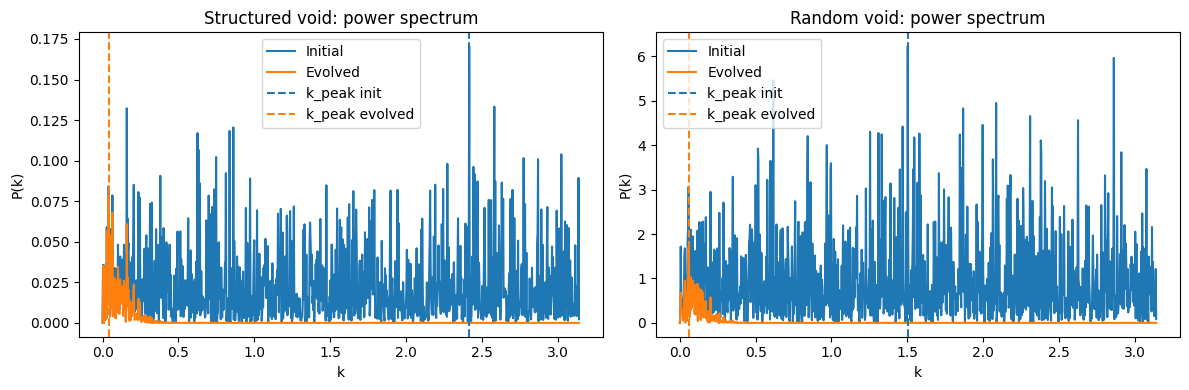

In [2]:
set_seed(7)

# Target echo scale
lambda0_target = 10.0
N = 2048

# Generate structured void vs random void
u_struct = gaussian_correlated_field(N=N, lambda0=lambda0_target, amplitude=1.0, noise=0.15)
u_random = np.random.randn(N) * 1.0

# HES parameters (tunable)
alpha, beta, gamma, dt, steps = 0.25, 0.02, 0.001, 0.2, 300

# Evolve both
u_struct_e = evolve_hes(u_struct, steps=steps, alpha=alpha, beta=beta, gamma=gamma, dt=dt, clip=5.0)
u_random_e = evolve_hes(u_random, steps=steps, alpha=alpha, beta=beta, gamma=gamma, dt=dt, clip=5.0)

# Spectral diagnostics
k_s, P_s0 = fft_power_spectrum(u_struct)
_, P_sE = fft_power_spectrum(u_struct_e)
k_r, P_r0 = fft_power_spectrum(u_random)
_, P_rE = fft_power_spectrum(u_random_e)

kpk_s0, lam_s0 = characteristic_scale_from_spectrum(k_s, P_s0)
kpk_sE, lam_sE = characteristic_scale_from_spectrum(k_s, P_sE)
kpk_r0, lam_r0 = characteristic_scale_from_spectrum(k_r, P_r0)
kpk_rE, lam_rE = characteristic_scale_from_spectrum(k_r, P_rE)

print(f"Structured void λ0 init: {lam_s0:.2f} → evolved: {lam_sE:.2f}")
print(f"Random void λ0 init:     {lam_r0:.2f} → evolved: {lam_rE:.2f}")

# Plot spectra comparison
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.title("Structured void: power spectrum")
plt.plot(k_s, P_s0, label="Initial")
plt.plot(k_s, P_sE, label="Evolved")
plt.axvline(kpk_s0, color='C0', ls='--', label='k_peak init')
plt.axvline(kpk_sE, color='C1', ls='--', label='k_peak evolved')
plt.xlabel("k"); plt.ylabel("P(k)"); plt.legend()

plt.subplot(1,2,2)
plt.title("Random void: power spectrum")
plt.plot(k_r, P_r0, label="Initial")
plt.plot(k_r, P_rE, label="Evolved")
plt.axvline(kpk_r0, color='C0', ls='--', label='k_peak init')
plt.axvline(kpk_rE, color='C1', ls='--', label='k_peak evolved')
plt.xlabel("k"); plt.ylabel("P(k)"); plt.legend()
plt.tight_layout(); plt.show()


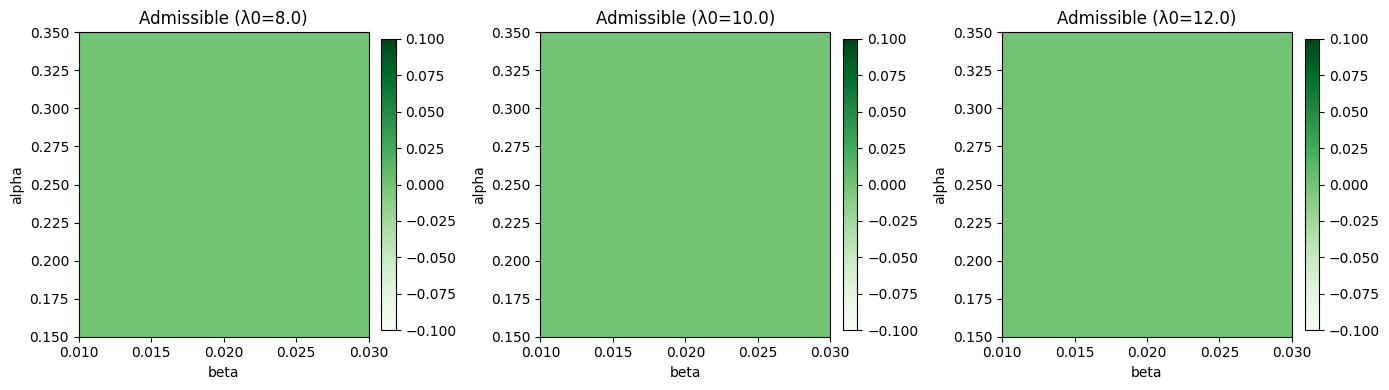

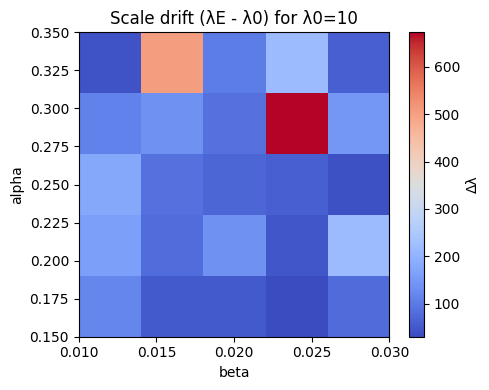

In [3]:
set_seed(11)

lambda_targets = [8.0, 10.0, 12.0]
alphas = np.linspace(0.15, 0.35, 5)
betas  = np.linspace(0.01, 0.03, 5)
gamma  = 0.001
dt, steps = 0.2, 250
tol = 1.5
N = 2048

def pass_constraint(u0, lambda_target, alpha, beta, gamma):
    uE = evolve_hes(u0, steps=steps, alpha=alpha, beta=beta, gamma=gamma, dt=dt, clip=5.0)
    k, P0 = fft_power_spectrum(u0)
    _, PE = fft_power_spectrum(uE)
    _, lam0 = characteristic_scale_from_spectrum(k, P0)
    _, lamE = characteristic_scale_from_spectrum(k, PE)
    return np.isfinite(lam0) and np.isfinite(lamE) and abs(lamE - lambda_target) < tol, lam0, lamE

results = {}
for lambda0 in lambda_targets:
    mask = np.zeros((len(alphas), len(betas)), dtype=int)
    drift = np.zeros_like(mask, dtype=float)
    for i, a in enumerate(alphas):
        for j, b in enumerate(betas):
            u0 = gaussian_correlated_field(N=N, lambda0=lambda0, amplitude=1.0, noise=0.2)
            ok, lam0, lamE = pass_constraint(u0, lambda0, a, b, gamma)
            mask[i,j] = 1 if ok else 0
            drift[i,j] = lamE - lambda0 if np.isfinite(lamE) else np.nan
    results[lambda0] = (mask, drift)

# Visualize admissible regions
fig, axes = plt.subplots(1, len(lambda_targets), figsize=(14,4))
for ax, lambda0 in zip(axes, lambda_targets):
    mask, drift = results[lambda0]
    im = ax.imshow(mask, origin='lower', cmap='Greens', extent=[betas[0],betas[-1],alphas[0],alphas[-1]], aspect='auto')
    ax.set_title(f"Admissible (λ0={lambda0})")
    ax.set_xlabel("beta"); ax.set_ylabel("alpha")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

# Optional: drift heatmap for λ0=10
lambda0 = 10.0
mask, drift = results[lambda0]
plt.figure(figsize=(5,4))
plt.title("Scale drift (λE - λ0) for λ0=10")
plt.imshow(drift, origin='lower', cmap='coolwarm',
           extent=[betas[0],betas[-1],alphas[0],alphas[-1]], aspect='auto')
plt.xlabel("beta"); plt.ylabel("alpha")
plt.colorbar(label="Δλ")
plt.tight_layout(); plt.show()


In [4]:
# Control: purely random void rarely passes
trials = 50
passes = 0
for t in range(trials):
    u_rand = np.random.randn(2048)
    ok, lam0, lamE = pass_constraint(u_rand, 10.0, alpha=0.25, beta=0.02, gamma=0.001)
    passes += int(ok)
print(f"Random void pass rate: {passes}/{trials}")

# Robustness: add stronger noise to structured void
u_noisy = gaussian_correlated_field(N=2048, lambda0=10.0, amplitude=1.0, noise=0.6)
ok, lam0, lamE = pass_constraint(u_noisy, 10.0, alpha=0.28, beta=0.02, gamma=0.001)
print(f"Structured noisy pass? {ok} | λ0={lam0:.2f} → λE={lamE:.2f}")


Random void pass rate: 0/50
Structured noisy pass? False | λ0=2.61 → λE=341.33
